# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "César Alberto Cázares Chaván"            # Tu nombre completo
MATRICULA = "82196"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: César Alberto Cázares Chaván
Matrícula: 82196
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


C:\Users\cesar\OneDrive\Universidad\5 semestre\Bid_Data\Examen Práctico Topicos de Big Data\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
print("Primer año:", df["year"].min())
print("Último año:", df["year"].max())
print("Años disponibles:")
print(sorted(df["year"].unique()))

Primer año: 2000
Último año: 2020
Años disponibles:
[np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [6]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [7]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [8]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [9]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [10]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset está completo: ninguna de sus cuatro columnas tiene valores nulos. Los datos
abarcan de 2000 a 2020 y `valor` es una variable numérica continua que representa un
porcentaje, por lo que sus resultados se pueden comparar directamente entre países y años.


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
# Pregunta 1
# Se excluyen agregados y se toma el año más reciente para no repetir países en el ranking.
df_paises = df[df[config["filtro_paises"]].notna()].copy()
anio_mas_reciente = int(df_paises["year"].max())

ranking_reciente = (
    df_paises.loc[df_paises["year"] == anio_mas_reciente]
    .dropna(subset=["valor"])
    .sort_values("valor", ascending=False)
)

top_10 = ranking_reciente.head(10)[["entity", "valor"]].reset_index(drop=True)
bottom_10 = (
    ranking_reciente.tail(10)[["entity", "valor"]]
    .sort_values("valor")
    .reset_index(drop=True)
)

print(f"Países distintos: {df_paises['entity'].nunique()}")
print(f"Año usado para el ranking: {anio_mas_reciente}")
print("\n10 países con el porcentaje más alto:")
display(top_10.style.format({"valor": "{:.2f}%"}))
print("10 países con el porcentaje más bajo:")
display(bottom_10.style.format({"valor": "{:.2f}%"}))


Países distintos: 189
Año usado para el ranking: 2020

10 países con el porcentaje más alto:


,entity,valor
0,Luxembourg,84.20%
1,Ireland,83.21%
2,Andorra,82.51%
3,Australia,80.67%
4,New Zealand,80.28%
5,Switzerland,79.96%
6,Austria,79.40%
7,Iceland,79.20%
8,Germany,78.83%
9,Denmark,78.29%


10 países con el porcentaje más bajo:


,entity,valor
0,Kuwait,0.83%
1,Somalia,0.92%
2,Comoros,0.95%
3,Yemen,1.15%
4,Libya,1.26%
5,Syria,1.50%
6,Iran,1.55%
7,Pakistan,1.57%
8,Mauritania,1.74%
9,Saudi Arabia,1.87%


**Interpretación:**

Después de quitar los agregados quedan 189 países. En 2020, Luxemburgo encabeza el
ranking con 84.20%, mientras que Kuwait tiene el valor más bajo con 0.83%. La distancia
entre los extremos es muy grande y muestra que el indicador cambia bastante entre países.


### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [12]:
# Pregunta 2
paises_p2 = ["Mexico", "Japan"]

limites_por_pais = (
    df_paises.loc[df_paises["entity"].isin(paises_p2)]
    .dropna(subset=["valor"])
    .groupby("entity")["year"]
    .agg(["min", "max"])
)

inicio_comun = int(limites_por_pais["min"].max())
fin_comun = int(limites_por_pais["max"].min())

comparacion_mexico_japon = (
    df_paises.loc[
        df_paises["entity"].isin(paises_p2)
        & df_paises["year"].between(inicio_comun, fin_comun),
        ["entity", "year", "valor"],
    ]
    .sort_values(["entity", "year"])
    .reset_index(drop=True)
)

print(f"Rango disponible para ambos países: {inicio_comun}-{fin_comun}")
display(comparacion_mexico_japon.style.format({"valor": "{:.2f}%"}))


Rango disponible para ambos países: 2000-2020


,entity,year,valor
0,Japan,2000,70.81%
1,Japan,2001,69.75%
2,Japan,2002,69.60%
3,Japan,2003,69.43%
4,Japan,2004,69.52%
5,Japan,2005,69.88%
6,Japan,2006,69.81%
7,Japan,2007,69.18%
8,Japan,2008,68.84%
9,Japan,2009,68.60%


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [13]:
# Pregunta 3
# Se eligió un país de América, Europa, África, Asia y Oceanía.
paises_p3 = ["Mexico", "Germany", "South Africa", "Japan", "Australia"]

anios_por_pais = [
    set(df_paises.loc[
        (df_paises["entity"] == pais) & df_paises["valor"].notna(), "year"
    ])
    for pais in paises_p3
]
anio_p3 = int(max(set.intersection(*anios_por_pais)))

comparacion_p3 = (
    df_paises.loc[
        df_paises["entity"].isin(paises_p3) & (df_paises["year"] == anio_p3),
        ["entity", "valor"],
    ]
    .dropna(subset=["valor"])
    .sort_values("valor", ascending=False)
    .reset_index(drop=True)
)

pais_mayor = comparacion_p3.iloc[0]
pais_menor = comparacion_p3.iloc[-1]
diferencia_p3 = pais_mayor["valor"] - pais_menor["valor"]

print(f"Año más reciente disponible para los cinco países: {anio_p3}")
display(comparacion_p3.style.format({"valor": "{:.2f}%"}))
print(f"Mayor: {pais_mayor['entity']} ({pais_mayor['valor']:.2f}%)")
print(f"Menor: {pais_menor['entity']} ({pais_menor['valor']:.2f}%)")
print(f"Diferencia: {diferencia_p3:.2f} puntos porcentuales")


Año más reciente disponible para los cinco países: 2020


,entity,valor
0,Australia,80.67%
1,Germany,78.83%
2,Japan,67.50%
3,Mexico,42.04%
4,South Africa,29.62%


Mayor: Australia (80.67%)
Menor: South Africa (29.62%)
Diferencia: 51.05 puntos porcentuales


**Interpretación:**

En 2020, Australia presenta el valor más alto con 80.67% y Sudáfrica el más bajo con
29.62%. La diferencia es de 51.05 puntos porcentuales, así que incluso dentro de una
muestra pequeña de continentes se ven niveles muy distintos de consumo reportado.


### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [14]:
# Pregunta 4
grupos = {
    "Latinoamérica": ["Mexico", "Colombia", "Argentina"],
    "Asia": ["China", "Japan", "Vietnam"],
}
paises_p4 = grupos["Latinoamérica"] + grupos["Asia"]

anios_por_pais = [
    set(df_paises.loc[
        (df_paises["entity"] == pais) & df_paises["valor"].notna(), "year"
    ])
    for pais in paises_p4
]
anio_p4 = int(max(set.intersection(*anios_por_pais)))

grupo_de_cada_pais = {
    pais: grupo
    for grupo, lista_paises in grupos.items()
    for pais in lista_paises
}

datos_p4 = df_paises.loc[
    df_paises["entity"].isin(paises_p4) & (df_paises["year"] == anio_p4),
    ["entity", "valor"],
].copy()
datos_p4["grupo"] = datos_p4["entity"].map(grupo_de_cada_pais)

promedios_p4 = (
    datos_p4.groupby("grupo", as_index=False)["valor"]
    .mean()
    .sort_values("valor", ascending=False)
    .reset_index(drop=True)
)

print(f"Año comparado: {anio_p4}")
print("Valores de los países:")
display(
    datos_p4[["grupo", "entity", "valor"]]
    .sort_values(["grupo", "valor"], ascending=[True, False])
    .style.format({"valor": "{:.2f}%"})
)
print("Promedio por grupo:")
display(promedios_p4.style.format({"valor": "{:.2f}%"}))


Año comparado: 2020
Valores de los países:


,grupo,entity,valor
1826,Asia,Japan,67.50%
755,Asia,China,60.26%
3865,Asia,Vietnam,53.70%
146,Latinoamérica,Argentina,71.02%
2309,Latinoamérica,Mexico,42.04%
776,Latinoamérica,Colombia,40.88%


Promedio por grupo:


,grupo,valor
0,Asia,60.49%
1,Latinoamérica,51.31%


**Interpretación:**

En 2020, el promedio de Asia fue 60.49% y el de Latinoamérica 51.31%, una diferencia
de 9.18 puntos. Japón eleva el promedio asiático y Argentina hace lo mismo en el grupo
latinoamericano, por eso conviene revisar también los datos individuales y no solo la media.


### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [15]:
# Pregunta 5
pais_p5 = "Mexico"
datos_mexico = (
    df_paises.loc[df_paises["entity"] == pais_p5, ["year", "valor"]]
    .dropna(subset=["valor"])
    .sort_values("year")
    .reset_index(drop=True)
)

registro_maximo = datos_mexico.loc[datos_mexico["valor"].idxmax()]
registro_minimo = datos_mexico.loc[datos_mexico["valor"].idxmin()]
cambios_anuales = datos_mexico["valor"].diff().dropna()

if (cambios_anuales >= 0).all():
    tendencia = "creciente"
elif (cambios_anuales <= 0).all():
    tendencia = "decreciente"
elif datos_mexico.iloc[-1]["valor"] >= datos_mexico.iloc[0]["valor"]:
    tendencia = "fluctuante, con aumento general"
else:
    tendencia = "fluctuante, con descenso general"

display(datos_mexico.style.format({"valor": "{:.2f}%"}))
print(f"Máximo: {registro_maximo['valor']:.2f}% en {int(registro_maximo['year'])}")
print(f"Mínimo: {registro_minimo['valor']:.2f}% en {int(registro_minimo['year'])}")
print(f"Tendencia: {tendencia}")


,year,valor
0,2000,43.70%
1,2001,43.49%
2,2002,43.31%
3,2003,43.46%
4,2004,43.57%
5,2005,43.67%
6,2006,44.07%
7,2007,42.53%
8,2008,42.63%
9,2009,42.77%


Máximo: 44.07% en 2006
Mínimo: 41.94% en 2013
Tendencia: fluctuante, con descenso general


**Interpretación:**

México se mantuvo cerca de 42% a 44% durante casi todo el periodo. Su máximo fue 44.07%
en 2006 y el mínimo 41.94% en 2013. No hay una subida o bajada continua; la serie fluctúa,
aunque termina por debajo de donde comenzó y presenta una caída marcada en 2020.


### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
mexico_ordenado = (
    df_paises.loc[df_paises["entity"] == "Mexico", ["year", "valor"]]
    .dropna(subset=["valor"])
    .sort_values("year")
    .reset_index(drop=True)
)

primer_registro = mexico_ordenado.iloc[0]
ultimo_registro = mexico_ordenado.iloc[-1]
cambio_porcentual = (
    (ultimo_registro["valor"] - primer_registro["valor"])
    / primer_registro["valor"]
    * 100
)

print(
    f"Primer dato: {primer_registro['valor']:.2f}% "
    f"({int(primer_registro['year'])})"
)
print(
    f"Último dato: {ultimo_registro['valor']:.2f}% "
    f"({int(ultimo_registro['year'])})"
)
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Primer dato: 43.70% (2000)
Último dato: 42.04% (2020)
Cambio porcentual: -3.80%


**Interpretación:**

Entre 2000 y 2020 el indicador de México cayó 3.80% en términos relativos. El cambio es
moderado porque la mayor parte de los años permanece en un rango parecido. Podría estar
relacionado con cambios en los hábitos y con las restricciones de 2020, pero este dataset
por sí solo no permite comprobar una causa.


### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [17]:
# Pregunta 7
anio_p7 = int(df_paises["year"].max())
valores_p7 = df_paises.loc[df_paises["year"] == anio_p7, "valor"].to_numpy(dtype=float)
valores_p7 = valores_p7[~np.isnan(valores_p7)]

media_p7 = np.mean(valores_p7)
mediana_p7 = np.median(valores_p7)
desviacion_p7 = np.std(valores_p7)

print(f"Año analizado: {anio_p7}")
print(f"Países con datos: {valores_p7.size}")
print(f"Media: {media_p7:.2f}%")
print(f"Mediana: {mediana_p7:.2f}%")
print(f"Desviación estándar: {desviacion_p7:.2f} puntos porcentuales")


Año analizado: 2020
Países con datos: 187
Media: 42.25%
Mediana: 42.04%
Desviación estándar: 24.00 puntos porcentuales


**Interpretación:**

En 2020, la media fue 42.25% y la mediana 42.04%, así que el centro de los datos es muy
parecido con ambas medidas. La desviación estándar fue de 24.00 puntos porcentuales, un
valor alto que confirma que hay bastante separación entre los países.


### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

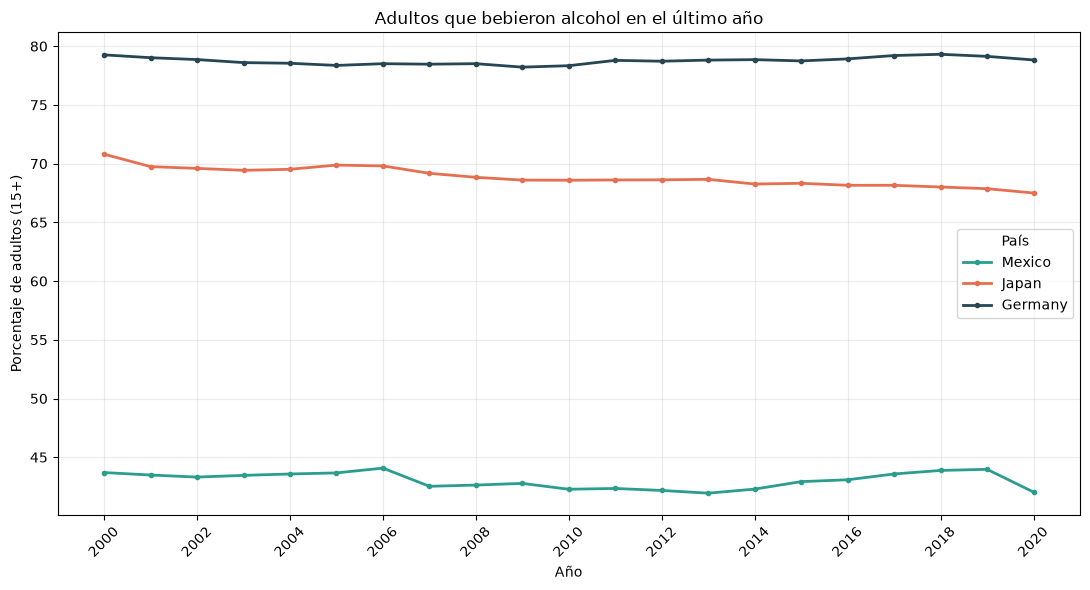

In [18]:
# Pregunta 8
paises_p8 = ["Mexico", "Japan", "Germany"]
colores_p8 = {"Mexico": "#2a9d8f", "Japan": "#e76f51", "Germany": "#264653"}

plt.figure(figsize=(11, 6))
for pais in paises_p8:
    datos_pais = (
        df_paises.loc[df_paises["entity"] == pais, ["year", "valor"]]
        .dropna(subset=["valor"])
        .sort_values("year")
    )
    plt.plot(
        datos_pais["year"],
        datos_pais["valor"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=pais,
        color=colores_p8[pais],
    )

plt.title("Adultos que bebieron alcohol en el último año")
plt.xlabel("Año")
plt.ylabel("Porcentaje de adultos (15+)")
plt.xticks(range(2000, 2021, 2), rotation=45)
plt.grid(alpha=0.25)
plt.legend(title="País")
plt.tight_layout()
plt.show()


**Interpretación:**

Alemania mantiene el nivel más alto y casi no cambia, cerca de 79%. Japón baja de 70.81%
a 67.50%, mientras México permanece entre 41.94% y 44.07%. Las tres series terminan con
una reducción en 2020, pero sus niveles siguen claramente separados.


### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

No hay datos de 2023; se usa 2020, el año disponible más cercano.


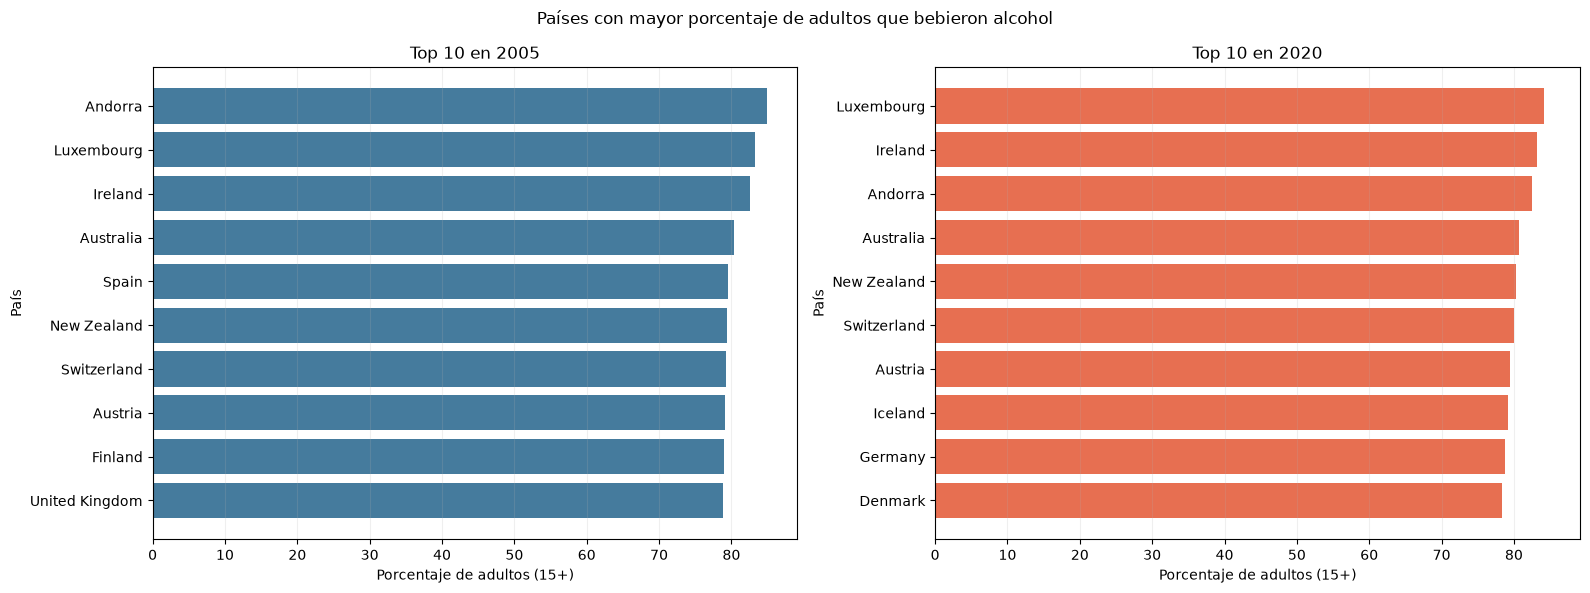

,entity,posicion_2005,posicion_2020
0,Luxembourg,2.0,1.0
1,Ireland,3.0,2.0
2,Andorra,1.0,3.0
3,Australia,4.0,4.0
4,New Zealand,6.0,5.0
5,Switzerland,7.0,6.0
6,Austria,8.0,7.0
7,Iceland,NaN,8.0
8,Germany,NaN,9.0
9,Denmark,NaN,10.0


In [19]:
# Pregunta 9
anio_nacimiento = 2005
anio_solicitado_final = 2023

anios_disponibles = np.sort(
    df_paises.loc[df_paises["valor"].notna(), "year"].unique()
)

def anio_mas_cercano(anio_solicitado):
    distancia = np.abs(anios_disponibles - anio_solicitado)
    return int(anios_disponibles[np.argmin(distancia)])


anio_grafica_1 = anio_mas_cercano(anio_nacimiento)
anio_grafica_2 = anio_mas_cercano(anio_solicitado_final)

if anio_grafica_2 != anio_solicitado_final:
    print(
        f"No hay datos de {anio_solicitado_final}; "
        f"se usa {anio_grafica_2}, el año disponible más cercano."
    )

top_por_anio = {}
for anio in [anio_grafica_1, anio_grafica_2]:
    top = (
        df_paises.loc[df_paises["year"] == anio, ["entity", "valor"]]
        .dropna(subset=["valor"])
        .sort_values("valor", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top["posicion"] = np.arange(1, len(top) + 1)
    top_por_anio[anio] = top

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
colores = ["#457b9d", "#e76f51"]

for eje, anio, color in zip(
    axes, [anio_grafica_1, anio_grafica_2], colores
):
    top = top_por_anio[anio].sort_values("valor")
    eje.barh(top["entity"], top["valor"], color=color)
    eje.set_title(f"Top 10 en {anio}")
    eje.set_xlabel("Porcentaje de adultos (15+)")
    eje.set_ylabel("País")
    eje.grid(axis="x", alpha=0.2)

fig.suptitle("Países con mayor porcentaje de adultos que bebieron alcohol")
plt.tight_layout()
plt.show()

# Tabla para revisar entradas, salidas y cambios de posición.
posiciones_1 = top_por_anio[anio_grafica_1][["entity", "posicion"]]
posiciones_2 = top_por_anio[anio_grafica_2][["entity", "posicion"]]
movimientos = posiciones_1.merge(
    posiciones_2,
    on="entity",
    how="outer",
    suffixes=(f"_{anio_grafica_1}", f"_{anio_grafica_2}"),
).sort_values(f"posicion_{anio_grafica_2}", na_position="last")

display(movimientos.reset_index(drop=True))


**Interpretación:**

El dataset no llega a 2023, así que la segunda gráfica usa 2020. Entre 2005 y 2020,
Luxemburgo e Irlanda subieron un lugar y Andorra bajó del primero al tercero. Australia
conservó el cuarto lugar. Islandia, Alemania y Dinamarca entraron al Top 10, mientras
España, Finlandia y Reino Unido salieron; los mayores cambios estuvieron al final del ranking.


## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

El dataset permitió comparar el porcentaje de adultos que bebió alcohol en 189 países.  
Encontré diferencias muy amplias: en 2020 los valores fueron desde 0.83% hasta 84.20%.  
México se mantuvo bastante estable, aunque terminó 3.80% por debajo de su valor de 2000.  
También vi que algunos países cambian poco, mientras otros muestran tendencias más claras.  
La media y la mediana mundial fueron cercanas, pero la desviación estándar resultó alta.  
Una limitación es que el indicador dice cuántas personas bebieron, no cuánto consumieron.  
Además, no hay datos posteriores a 2020, por lo que no fue posible consultar 2023.  
Con más tiempo agregaría variables como consumo por persona, edad e ingreso para buscar relaciones.


## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
